# Channel unmixing

Separating spectrally-distinct dye populations imaged simultaneously on one Bayer sensor.
`unmix_channels` classifies each molecule into a dye/channel by its spectral fraction
columns (`A_R`/`A_G`/`A_B` — how its photons split across the Bayer colour channels), not
by position.

Data: `test_tiffs/channel_unmixing/` — two dyes (Cy3B, Alexa Fluor 647) in two spatially
distinct regions of the same field of view. Both dyes are fit with one shared PSF-sigma
wavelength (see the fixture's own `README.md`) — `unmix_channels` separates them by colour
fraction, not by any difference in spot size.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline, FittingConfig
from pyS3M.Constants import AnalysisConfig
from pyS3M.clustering import ClusteringConfig

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "test_tiffs" / "channel_unmixing"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)

fc = FittingConfig(peak_wavelength=0.644, pfa=1e-3)
pipe.fit(DATA_DIR, mode="smlm", fitting_config=fc)

locs = pipe.load_localisations(DATA_DIR)
sm_db, sf_db = pipe.filter_and_cluster(locs)
print(f"{len(sm_db)} molecules from {len(sf_db)} quality-filtered localisations")

Detecting puncta:   0%|          | 0/400 [00:00<?, ?it/s]

31 molecules from 835 quality-filtered localisations


## Unmix

`pipe.sm.unmix_channels` lives on the `extract_SMs` instance (`pipe.sm`), not on
`AnalysisPipeline` directly — same object `filter_and_cluster` delegates clustering to
internally.

In [2]:
assigned, metadata = pipe.sm.unmix_channels(
    sm_db, n_channels=2, channels_to_use=["A_R", "A_G"],
    confidence_threshold=0.6, outlier_rejection="none",
    verbose=True, plot_results=False,
)
channel_counts = assigned.loc[assigned["channel"] >= 0, "channel"].value_counts().sort_index()
n_unassigned = int((assigned["channel"] < 0).sum())
print(f"Channel split: {channel_counts.to_dict()}  ({n_unassigned} unassigned)")

Channel split: {0: 14, 1: 17}  (0 unassigned)


## Render — spectral feature space and spatial split, side by side

/tmp/ipykernel_3614803/2602672482.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


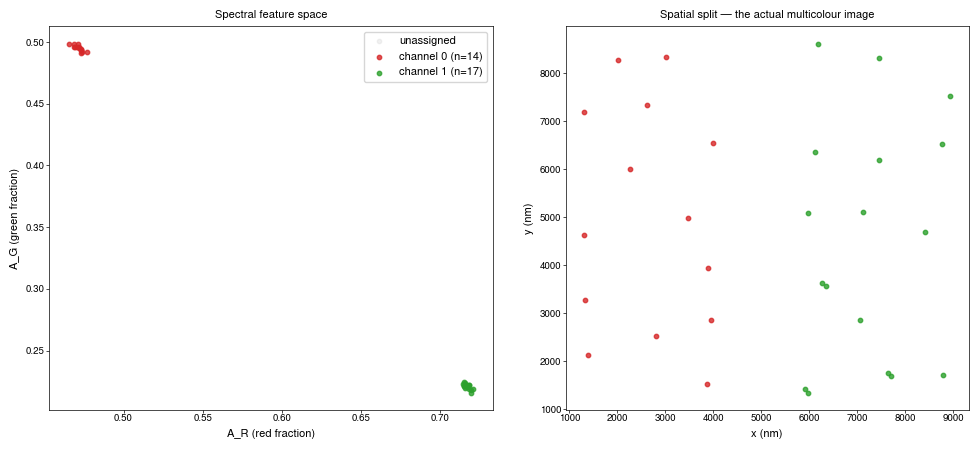

In [3]:
colors = ["tab:red", "tab:green", "tab:blue"]
fig, (ax_spec, ax_spatial) = plt.subplots(1, 2, figsize=(10, 4.5))

unassigned = assigned["channel"] < 0
ax_spec.scatter(assigned.loc[unassigned, "A_R"], assigned.loc[unassigned, "A_G"],
                 s=10, alpha=0.3, color="lightgray", label="unassigned")
ax_spatial.scatter(assigned.loc[unassigned, "xc"], assigned.loc[unassigned, "yc"],
                    s=6, alpha=0.2, color="lightgray")

for k in sorted(int(c) for c in assigned["channel"].unique() if c >= 0):
    mask = assigned["channel"] == k
    c = colors[k % len(colors)]
    ax_spec.scatter(assigned.loc[mask, "A_R"], assigned.loc[mask, "A_G"], s=10, alpha=0.8, color=c, label=f"channel {k} (n={int(mask.sum())})")
    ax_spatial.scatter(assigned.loc[mask, "xc"] * pipe.pixel_size * 1000, assigned.loc[mask, "yc"] * pipe.pixel_size * 1000, s=10, alpha=0.8, color=c)

ax_spec.set_xlabel("A_R (red fraction)")
ax_spec.set_ylabel("A_G (green fraction)")
ax_spec.set_title("Spectral feature space")
ax_spec.legend(fontsize=8)
ax_spatial.set_xlabel("x (nm)")
ax_spatial.set_ylabel("y (nm)")
ax_spatial.set_aspect("equal")
ax_spatial.set_title("Spatial split — the actual multicolour image")
plt.tight_layout()
plt.show()

## Next: `06_nile_red_pixelated_wavelength_fit.ipynb`